In [ ]:
# cell 1
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, "/content/drive/MyDrive/CV_PROJECT")
print("✅ Session ready!")

Mounted at /content/drive
✅ Session ready!


In [ ]:
# cell 2
project_path = "/content/drive/MyDrive/CV_PROJECT"

ui_overlay_code = '''# ui_overlay.py
# Draws prediction results directly onto the video frame.
# All drawing uses OpenCV — no external libraries needed.

import cv2


def draw_prediction(frame, letter, confidence):
    """
    Draws the predicted letter and confidence bar
    in the top-left corner of the frame.
    """
    if letter is None:
        return frame

    overlay = frame.copy()

    # --- Black background box for letter ---
    cv2.rectangle(overlay, (10, 10), (130, 80), (0, 0, 0), -1)
    cv2.addWeighted(overlay, 0.6, frame, 0.4, 0, frame)

    # --- Big predicted letter ---
    cv2.putText(
        frame,
        str(letter),
        (30, 72),
        cv2.FONT_HERSHEY_SIMPLEX,
        2.4,            # font scale — big and readable
        (0, 255, 136),  # bright green
        4,              # thickness
        cv2.LINE_AA
    )

    # --- Confidence bar background (gray) ---
    cv2.rectangle(frame, (10, 88), (130, 104), (50, 50, 50), -1)

    # --- Confidence bar fill (green, scales with confidence) ---
    bar_width = int(120 * confidence)
    cv2.rectangle(frame, (10, 88), (10 + bar_width, 104), (0, 200, 100), -1)

    # --- Confidence percentage text ---
    conf_text = f"{int(confidence * 100)}%"
    cv2.putText(
        frame,
        conf_text,
        (45, 101),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.45,
        (255, 255, 255),
        1,
        cv2.LINE_AA
    )

    return frame


def draw_no_hand(frame):
    """
    Shows a subtle message when no hand is detected.
    """
    cv2.putText(
        frame,
        "No hand detected",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (60, 60, 200),   # muted blue
        2,
        cv2.LINE_AA
    )
    return frame


def draw_low_confidence(frame, confidence):
    """
    Shows when a hand is detected but confidence is too low.
    """
    cv2.putText(
        frame,
        f"Low confidence: {int(confidence * 100)}%",
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        (0, 165, 255),   # orange
        2,
        cv2.LINE_AA
    )
    return frame


def draw_hand_count(frame, num_hands):
    """
    Shows how many hands are currently detected — top right corner.
    """
    text  = f"Hands: {num_hands}"
    color = (0, 255, 0) if num_hands > 0 else (100, 100, 100)

    cv2.putText(
        frame,
        text,
        (frame.shape[1] - 140, 30),   # top right
        cv2.FONT_HERSHEY_SIMPLEX,
        0.65,
        color,
        2,
        cv2.LINE_AA
    )
    return frame


def draw_title(frame):
    """
    Draws app title at the bottom of the frame.
    """
    h = frame.shape[0]
    cv2.putText(
        frame,
        "ISL Recognition",
        (10, h - 15),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        (180, 180, 180),
        1,
        cv2.LINE_AA
    )
    return frame


def apply_full_overlay(frame, letter, confidence, num_hands):
    """
    Master function — applies ALL overlays in one call.
    This is what main.py will use.

    Args:
        frame      : BGR OpenCV frame
        letter     : predicted letter string, or None
        confidence : float 0.0 to 1.0
        num_hands  : int, how many hands MediaPipe detected

    Returns:
        frame with all overlays drawn on it
    """
    # Always show hand count and title
    frame = draw_hand_count(frame, num_hands)
    frame = draw_title(frame)

    # Show appropriate prediction state
    if num_hands == 0:
        frame = draw_no_hand(frame)
    elif letter is None:
        frame = draw_low_confidence(frame, confidence)
    else:
        frame = draw_prediction(frame, letter, confidence)

    return frame
'''

with open(f"{project_path}/ui_overlay.py", "w") as f:
    f.write(ui_overlay_code)

print("✅ ui_overlay.py created!")

✅ ui_overlay.py created!


In [ ]:
# cell 3
!pip install mediapipe==0.10.33 scikit-learn==1.6.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.8 MB/s eta 0:00:00


⏱️  27.6s / 30s  |  🖐 Hands: 0  |  👀 Waiting...
---------------------------------------------


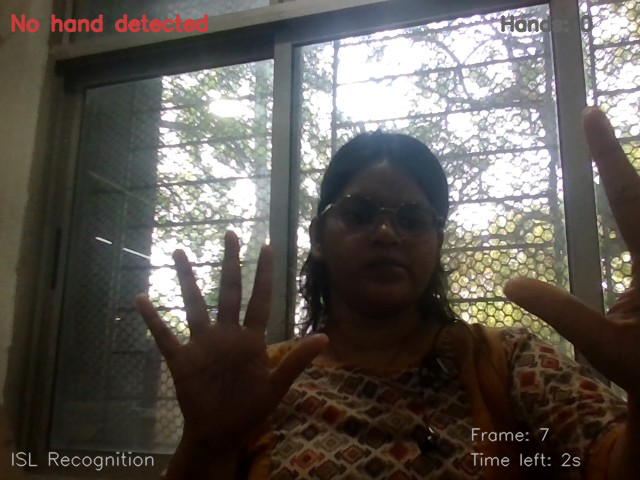


⏱️ Session complete!

🔴 Turning camera off...


<IPython.core.display.Javascript object>

✅ Camera closed. Session ended.
   Total frames captured: 7


In [ ]:
# cell 4
import importlib
import config, utils, model_loader, ui_overlay
for mod in [config, utils, model_loader, ui_overlay]:
    importlib.reload(mod)

from IPython.display import display, Javascript, clear_output
from google.colab.output import eval_js
from base64 import b64decode
import numpy as np
import cv2
from PIL import Image
import io
import time

# ─── HOW LONG TO RUN ────────────────────────────────────
DURATION_SECONDS = 30   # camera stays active for 30 seconds
FRAME_DELAY      = 1.5  # seconds between each capture
# ────────────────────────────────────────────────────────


def capture_frame_js():
    """
    Captures a single frame from the webcam.
    Camera stays open between calls — we only stop it manually.
    """
    js_code = Javascript('''
        async function captureFrame() {
            // Reuse existing stream if already open
            if (!window._isl_stream || window._isl_stream.getTracks()[0].readyState === 'ended') {
                window._isl_stream = await navigator.mediaDevices.getUserMedia({
                    video: { width: 640, height: 480 }
                });
                window._isl_video = document.createElement('video');
                window._isl_video.srcObject = window._isl_stream;
                window._isl_video.style.display = 'none';
                document.body.appendChild(window._isl_video);
                await window._isl_video.play();
                // Warmup time — only on first open
                await new Promise(resolve => setTimeout(resolve, 1500));
            }

            // Capture current frame
            const canvas = document.createElement('canvas');
            canvas.width  = window._isl_video.videoWidth  || 640;
            canvas.height = window._isl_video.videoHeight || 480;
            canvas.getContext('2d').drawImage(window._isl_video, 0, 0);

            return canvas.toDataURL('image/jpeg', 0.9);
        }
        captureFrame()
            .then(r => element.textContent = r)
            .catch(e => element.textContent = 'ERROR:' + e.message);
    ''')
    display(js_code)
    result = eval_js('captureFrame()', timeout_sec=15)

    if result.startswith('ERROR'):
        print(f"⚠️ Camera error: {result}")
        return None

    image_bytes = b64decode(result.split(',')[1])
    frame       = np.array(Image.open(io.BytesIO(image_bytes)))
    return cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)


def stop_camera():
    """Turns off the webcam after the session ends."""
    display(Javascript('''
        if (window._isl_stream) {
            window._isl_stream.getTracks().forEach(t => t.stop());
            window._isl_video && window._isl_video.remove();
            window._isl_stream = null;
            element.textContent = 'camera stopped';
        }
    '''))
    eval_js('(async () => "done")()')


def show_frame(frame):
    """Displays frame inline — clears previous to simulate live feel."""
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    display(Image.fromarray(frame_rgb))


# --- Load model + detector once ---
print("🔧 Loading model and detector...")
model    = model_loader.load_model(config.MODEL_PATH)
detector = utils.init_mediapipe(
    model_path     = config.MEDIAPIPE_MODEL_PATH,
    max_hands      = config.MAX_HANDS,
    detection_conf = config.DETECTION_CONFIDENCE,
    tracking_conf  = config.TRACKING_CONFIDENCE
)

print(f"\n📸 Starting real-time session ({DURATION_SECONDS} seconds)...")
print("👋 Show your ISL hand signs to the camera!\n")
print("=" * 45)

start_time   = time.time()
frame_count  = 0
last_letter  = None

try:
    while True:
        elapsed = time.time() - start_time

        # Stop after duration
        if elapsed > DURATION_SECONDS:
            print("\n⏱️ Session complete!")
            break

        # Capture frame
        frame = capture_frame_js()
        if frame is None:
            continue

        frame      = cv2.resize(frame, (config.FRAME_WIDTH, config.FRAME_HEIGHT))
        frame_count += 1

        # Detect hands
        results, frame = utils.detect_hand(frame, detector)
        num_hands      = len(results.hand_landmarks)

        # Extract + predict
        landmarks          = utils.extract_landmarks(results)
        normalized         = utils.normalize_landmarks(landmarks)
        letter, confidence = model_loader.predict_letter(model, normalized)

        # Draw overlay
        frame = ui_overlay.apply_full_overlay(frame, letter, confidence, num_hands)

        # Add timer to frame so user knows how long is left
        remaining = int(DURATION_SECONDS - elapsed)
        cv2.putText(
            frame,
            f"Time left: {remaining}s",
            (config.FRAME_WIDTH - 170, config.FRAME_HEIGHT - 15),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (180, 180, 180),
            1,
            cv2.LINE_AA
        )

        # Add frame counter
        cv2.putText(
            frame,
            f"Frame: {frame_count}",
            (config.FRAME_WIDTH - 170, config.FRAME_HEIGHT - 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.55,
            (180, 180, 180),
            1,
            cv2.LINE_AA
        )

        # Clear previous frame output and show new one
        clear_output(wait=True)

        # Status line above the frame
        status = f"🔤 {letter} ({confidence*100:.0f}%)" if letter else "👀 Waiting..."
        print(f"⏱️  {elapsed:.1f}s / {DURATION_SECONDS}s  |  🖐 Hands: {num_hands}  |  {status}")
        print("-" * 45)

        show_frame(frame)

        # Wait before next capture
        time.sleep(FRAME_DELAY)

except KeyboardInterrupt:
    print("\n⛔ Stopped manually.")

finally:
    # Always turn camera off at the end
    print("\n🔴 Turning camera off...")
    stop_camera()
    print("✅ Camera closed. Session ended.")
    print(f"   Total frames captured: {frame_count}")

In [ ]:
project_path = "/content/drive/MyDrive/CV_PROJECT"

utils_code = '''# utils.py
# Helper functions for hand detection and landmark processing.

import cv2
import numpy as np
import mediapipe as mp


def init_mediapipe(
    model_path='models/hand_landmarker.task',
    max_hands=1,
    detection_conf=0.5,
    tracking_conf=0.5,
):
    """
    Initializes and returns a MediaPipe HandLandmarker object.
    """
    # ---------------- MediaPipe setup ---------------------
    # Options for MediaPipe HandLandmarker
    base_options = mp.tasks.BaseOptions(model_asset_path=model_path)
    options = mp.tasks.vision.HandLandmarkerOptions(
        base_options=base_options,
        num_hands=max_hands,
        min_hand_detection_confidence=detection_conf,
        min_tracking_confidence=tracking_conf,
    )

    # Create a hand landmarker object
    detector = mp.tasks.vision.HandLandmarker.create_from_options(options)

    return detector


def detect_hand(frame, detector):
    """
    Detects hands in a given frame using the MediaPipe detector.

    Returns:
        (detection_result, frame_with_landmarks) tuple
    """
    # Convert the frame to MediaPipe Image format
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)

    # Perform hand landmark detection
    detection_result = detector.detect(mp_image)

    # Draw landmarks on the frame
    frame_copy = np.copy(frame)
    if detection_result.hand_landmarks:
        for hand_landmarks in detection_result.hand_landmarks:
            mp.solutions.drawing_utils.draw_landmarks(
                frame_copy,
                hand_landmarks,
                mp.solutions.hands.HAND_CONNECTIONS,
                mp.solutions.drawing_styles.get_default_hand_landmarks_style(),
                mp.solutions.drawing_styles.get_default_hand_connections_style(),
            )
    return detection_result, frame_copy


def extract_landmarks(results):
    """
    Extracts landmark coordinates from MediaPipe results.
    Handles single and dual-hand scenarios.
    Returns a flattened list of (x,y,z) coordinates.
    """
    num_hands = len(results.hand_landmarks)

    if num_hands == 0:
        return []

    # Process first hand
    hand1_landmarks = []
    for landmark in results.hand_landmarks[0]:
        hand1_landmarks.extend([landmark.x, landmark.y, landmark.z])

    # If two hands, process second hand and concatenate
    if num_hands == 2:
        hand2_landmarks = []
        for landmark in results.hand_landmarks[1]:
            hand2_landmarks.extend([landmark.x, landmark.y, landmark.z])
        return hand1_landmarks + hand2_landmarks

    # Only one hand detected
    return hand1_landmarks


def normalize_landmarks(landmarks):
    """
    Normalizes landmark coordinates relative to the wrist (first landmark).
    Translates all points so wrist is at (0,0,0).
    """
    if not landmarks:
        return np.array([])

    # Reshape into (N, 3) for easier manipulation (N landmarks, 3 coords)
    landmarks_array = np.array(landmarks).reshape(-1, 3)

    # The first landmark is the wrist (index 0)
    wrist_x, wrist_y, wrist_z = landmarks_array[0]

    # Subtract wrist coordinates from all other landmarks
    normalized_array = landmarks_array - np.array([wrist_x, wrist_y, wrist_z])

    # Flatten back to a 1D array
    return normalized_array.flatten()
'''

with open(f"{project_path}/utils.py", "w") as f:
    f.write(utils_code)

print("✅ utils.py created!")

✅ utils.py created!
